# Randomized Pivoted Cholesky

In [46]:
import numpy as np

def rpcholesky(A, k):
    """
    RPCholesky algorithm for Nyström approximation of a PSD matrix.

    Parameters:
    A : numpy.ndarray
        Input PSD matrix (real or complex Hermitian) of shape (N, N).
    k : int
        Approximation rank (number of pivots).

    Returns:
    S : list of int
        List of selected pivot indices.
    F : numpy.ndarray
        Matrix of shape (N, k) such that F @ F.conj().T is the Nyström approximation.
    """
    N = A.shape[0]
    F = np.zeros((N, k), dtype=np.complex128)  # Use complex dtype to handle both cases
    d = np.diag(A).real.copy()  # Diagonal is real for PSD matrices
    S = []
    for i in range(k):
        # Check if residual diagonal has non-zero sum
        total = np.sum(d)
        if np.max(d) <= 1e-14:  # Early stop if residual is negligible
            break
        # Sample pivot with probability proportional to d
        prob = d / total
        s_i = np.random.choice(N, p=prob)
        S.append(s_i)
        # Normalize by sqrt(g[s_i]) and handle potential division by zero
        g_si = d[s_i]  # Must be real and non-negative for PSD
        if g_si <= 0 :
            print(len(S))
            print(g_si)
            raise ValueError("Diagonal entry is non-positive, numerical error detected.")
        #if g_si < 10e-14 :
        #    i-=1
        #    print('error')
        #    continue
        #Compute the selected column of A and subtract previous projections
        g = A[:, s_i].astype(np.complex128)
        if i > 0:
            proj = F[:, :i] @ F[s_i, :i].conj().T
            g -= proj

        
            
        F[:, i] = g / np.sqrt(g_si)

        # Update the residual diagonal and ensure non-negativity
        d -= np.abs(F[:, i])**2
        d = np.maximum(d, 0)
    return S, F



# Test Example with Diagonal Matrix and Random PSD Matrix

In [47]:
# Test 1: Diagonal matrix with known structure
def test_diagonal_case():
    np.random.seed(42)  # For reproducibility
    N = 9
    diag_entries = np.array([6.0, 5.0, 4.0, 3.0, 2.0, 1.0, 0.1, 0.05, 0.03])
    A = np.diag(diag_entries)  # Diagonal PSD matrix
    k = 6
    
    # Run RPCholesky
    S, F = rpcholesky(A, k)
    F = F.astype(np.float64)  # Ensure real output for diagonal case
    A_hat = F @ F.T
    
    # Compute relative trace error
    error_trace = np.trace(A - A_hat)
    rel_error = error_trace / np.trace(A)
    print(f"Test 1 (Diagonal Matrix):")
    print(f"  Selected pivots: {S}")
    print(f"  Relative trace error: {rel_error:.4f}\n")

# Test 2: Random PSD matrix
def test_random_psd_case():
    np.random.seed(42)
    N = 1000
    rank = 70  # Rank of the underlying matrix
    X = np.random.randn(N, rank)
    A = X @ X.T  # Construct a low-rank PSD matrix
    k = 66
    
    # Run RPCholesky
    S, F = rpcholesky(A, k)
    A_hat = F @ F.T
    
    # Compute relative trace error
    error_trace = np.trace(A - A_hat)
    rel_error = error_trace / np.trace(A)
    print(f"Test 2 (Random Low-Rank PSD Matrix):")
    print(f"  Relative trace error: {rel_error:.4f}")

# Run tests
test_diagonal_case()
test_random_psd_case()

Test 1 (Diagonal Matrix):
  Selected pivots: [1, 5, 3, 2, 0, 4]
  Relative trace error: 0.0085

Test 2 (Random Low-Rank PSD Matrix):
  Relative trace error: 0.0524+0.0000j


/var/folders/g3/0t8gwj_17y79jvr3k3mg9g440000gn/T/ipykernel_70338/1883851399.py:11: ComplexWarning: Casting complex values to real discards the imaginary part
  F = F.astype(np.float64)  # Ensure real output for diagonal case


# Greedy Pivoting

In [48]:
import numpy as np

def greedy_pivoted_cholesky(A, k):
    """
    Greedy pivoted Cholesky decomposition for Nyström approximation.

    Parameters:
    A : numpy.ndarray
        Input PSD matrix (real or complex Hermitian) of shape (N, N).
    k : int
        Approximation rank (number of pivots).

    Returns:
    S : list of int
        List of selected pivot indices.
    F : numpy.ndarray
        Matrix of shape (N, k) such that F @ F.conj().T is the Nyström approximation.
    """
    N = A.shape[0]
    F = np.zeros((N, k), dtype=np.complex128)
    d = np.diag(A).real.copy()  # Diagonal is real for PSD matrices
    S = []

    for i in range(k):   
        if np.max(d) <= 1e-14:  # Early stop if residual is negligible
            break
        # Select pivot with largest diagonal entry
        s_i = np.argmax(d)
        S.append(s_i)
                 # Normalize and handle numerical issues
        g_si =d[s_i]
       # if g_si < 10e-14 :
       #     i-=1
       #     continue
        if g_si <= 0 :
           print(len(S))
           print(g_si)
           raise ValueError("Diagonal entry is non-positive, numerical error detected.")
        

        # Compute column and subtract previous projections
        g = A[:, s_i].astype(np.complex128)
        if i > 0:
            proj = F[:, :i] @ F[s_i, :i].conj().T
            g -= proj

    
        F[:, i] = g / np.sqrt(g_si)

        # Update residual diagonal
        d -= np.abs(F[:, i])**2
        d = np.maximum(d, 0)
    return S, F


# Uniform Pivoting

In [49]:

def uniform_pivoted_cholesky(A, k):
    """
    Uniform random pivoted Cholesky decomposition for Nyström approximation (without replacement).

    Parameters:
    A : numpy.ndarray
        Input PSD matrix (real or complex Hermitian) of shape (N, N).
    k : int
        Approximation rank (number of pivots), must be <= N.

    Returns:
    S : list of int
        List of selected pivot indices.
    F : numpy.ndarray
        Matrix of shape (N, k) such that F @ F.conj().T is the Nyström approximation.
    """
    N = A.shape[0]
    if k > N:
        raise ValueError("k must be less than or equal to N when sampling without replacement.")

    F = np.zeros((N, k), dtype=np.complex128)
    d = np.diag(A).real.copy()
    S = []
    unchosen = list(range(N))

    for i in range(k):
        # Randomly sample one index without replacement
        s_i = np.random.choice(unchosen)
        unchosen.remove(s_i)
        S.append(s_i)

        g_si = d[s_i]
        if g_si < 1e-14:
            # If pivot is numerically zero, skip this iteration
            continue

        g = A[:, s_i].astype(np.complex128)

        if i > 0:
            proj = F[:, :i] @ F[s_i, :i].conj().T
            g -= proj

        F[:, i] = g / np.sqrt(g_si)

        # Update diagonal residuals
        d -= np.abs(F[:, i])**2
        d = np.maximum(d, 0)

    return S, F


 




# Test for Uniform and Greedy Pivoting

In [50]:
def test_greedy_and_uniform():
    np.random.seed(42)

    # Test 1: Diagonal matrix
    N = 9
    A = np.diag([6.0, 5.0, 4.0, 3.0, 2.0, 1.0, 0.1, 0.05, 0.03])
    k = 8

    # Greedy pivoting
    S_greedy, F_greedy = greedy_pivoted_cholesky(A, k)
    A_hat_greedy = F_greedy @ F_greedy.T.conj()
    error_greedy = np.trace(A - A_hat_greedy) / np.trace(A)

    # Uniform pivoting
    S_uniform, F_uniform = uniform_pivoted_cholesky(A, k)
    A_hat_uniform = F_uniform @ F_uniform.T.conj()
    error_uniform = np.trace(A - A_hat_uniform) / np.trace(A)

    print("Test 1 (Diagonal Matrix):")
    print(f"  Greedy pivots: {S_greedy} | Relative trace error: {error_greedy:.4f}")
    print(f"  Uniform pivots: {S_uniform} | Relative trace error: {error_uniform:.4f}\n")

    # Test 2: Random low-rank PSD matrix
    N = 100
    rank = 20
    X = np.random.randn(N, rank)
    A = X @ X.T
    k = 18

    # Greedy pivoting
    _, F_greedy = greedy_pivoted_cholesky(A, k)
    A_hat_greedy = F_greedy @ F_greedy.T.conj()
    error_greedy = np.trace(A - A_hat_greedy) / np.trace(A)

    # Uniform pivoting
    _, F_uniform = uniform_pivoted_cholesky(A, k)
    A_hat_uniform = F_uniform @ F_uniform.T.conj()
    error_uniform = np.trace(A - A_hat_uniform) / np.trace(A)

    print("Test 2 (Random Low-Rank PSD Matrix):")
    print(f"  Greedy relative trace error: {error_greedy:.4f}")
    print(f"  Uniform relative trace error: {error_uniform:.4f}")

test_greedy_and_uniform()

Test 1 (Diagonal Matrix):
  Greedy pivots: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)] | Relative trace error: 0.0014+0.0000j
  Uniform pivots: [np.int64(6), np.int64(3), np.int64(5), np.int64(2), np.int64(8), np.int64(0), np.int64(7), np.int64(4)] | Relative trace error: 0.2361+0.0000j

Test 2 (Random Low-Rank PSD Matrix):
  Greedy relative trace error: 0.0635+0.0000j
  Uniform relative trace error: 0.0827+0.0000j


# Numerical Test Example with Artificial Data

Testing on Smile Dataset (σ = 2.0):
  RPCholesky: Relative Trace Error = 4.8205e-14
  Greedy: Relative Trace Error = 1.3879e-15
  Uniform: Relative Trace Error = 2.6708e-03

Testing on Spiral Dataset (σ = 1000):
  RPCholesky: Relative Trace Error = 3.9001e-01
  Greedy: Relative Trace Error = 8.8965e-01
  Uniform: Relative Trace Error = 4.1945e-01


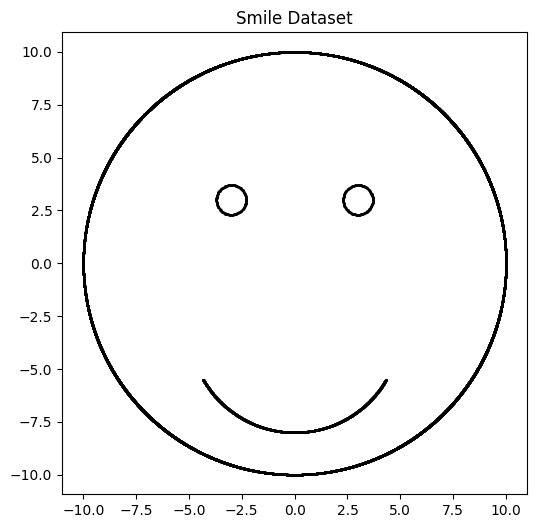

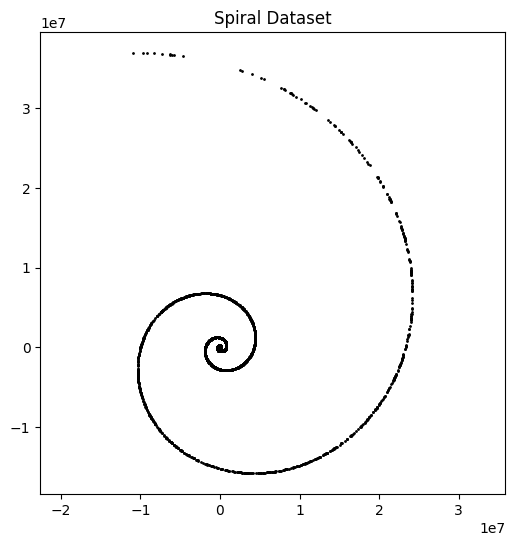

In [51]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# =============================================
# 1. Dataset Generation
# =============================================


def generate_smile(N_face=9000, N_mouth=900, N_eye=100):
    """Generate a smiley face point cloud."""
    
    # Face outline (large circle)
    theta_face = np.linspace(0, 2 * np.pi, N_face)
    face_radius = 10
    x_face = face_radius * np.cos(theta_face)
    y_face = face_radius * np.sin(theta_face)
    
    # Eyes (small circles)
    eye_radius = 0.7
    theta_eye = np.linspace(0, 2 * np.pi, N_eye)
    
    left_eye_x = -3 + eye_radius * np.cos(theta_eye)
    left_eye_y = 3 + eye_radius * np.sin(theta_eye)
    
    right_eye_x = 3 + eye_radius * np.cos(theta_eye)
    right_eye_y = 3 + eye_radius * np.sin(theta_eye)
    
    # Mouth (semicircle arc in lower half)
    theta_mouth = np.linspace(np.pi/6, 5*np.pi/6, N_mouth)
    mouth_radius = 5
    x_mouth = mouth_radius * np.cos(theta_mouth)
    y_mouth = -mouth_radius * np.sin(theta_mouth) - 3  # Shift downward

    # Stack all points
    x_all = np.concatenate([x_face, left_eye_x, right_eye_x, x_mouth])
    y_all = np.concatenate([y_face, left_eye_y, right_eye_y, y_mouth])
    
    return np.column_stack([x_all, y_all])


def generate_spiral(N=10000):
    """Generate logarithmic spiral with non-uniform sampling."""
    t = np.linspace(0, 64, N)
    t += 0.5 * np.random.randn(N)  # Add noise to make sampling non-uniform
    r = np.exp(0.27 * t)
    x = r * np.cos(t)
    y = r * np.sin(t)
    return np.column_stack([x, y])

# =============================================
# 2. Gaussian Kernel Matrix
# =============================================

def gaussian_kernel(X, sigma):
    """Compute Gaussian kernel matrix."""
    sq_dists = np.sum(X**2, axis=1)[:, None] + np.sum(X**2, axis=1) - 2 * X @ X.T
    return np.exp(-sq_dists / (2 * sigma**2))

# =============================================
# 3. Test Pivoting Methods
# =============================================

def test_methods(X, sigma, k=100):
    """Test RPCholesky, greedy, and uniform pivoting on a dataset."""
    # Compute kernel matrix
    A = gaussian_kernel(X, sigma)
    
    # Test all methods
    methods = {
        "RPCholesky": rpcholesky,
        "Greedy": greedy_pivoted_cholesky,
        "Uniform": uniform_pivoted_cholesky
    }
    
    results = {}
    for name, method in methods.items():
        S, F = method(A, k)
        A_hat = F @ F.T.conj()
        error = np.trace(A - A_hat) / np.trace(A)
        results[name] = error
    
    return results

# =============================================
# 4. Run Experiments
# =============================================

# Generate datasets
np.random.seed(42)
smile_data = generate_smile()
spiral_data = generate_spiral()

# Test on Smile dataset (σ = 2.0)
print("Testing on Smile Dataset (σ = 2.0):")
smile_results = test_methods(smile_data, sigma=2.0, k=300)
for method, error in smile_results.items():
    print(f"  {method}: Relative Trace Error = {abs(error.real):.4e}")

# Test on Spiral dataset (σ = 1000)
print("\nTesting on Spiral Dataset (σ = 1000):")
spiral_results = test_methods(spiral_data, sigma=1000, k=300)
for method, error in spiral_results.items():
    print(f"  {method}: Relative Trace Error = {abs(error.real):.4e}")

# =============================================
# 5. Visualization
# =============================================

def plot_dataset(X, title):
    plt.figure(figsize=(6, 6))
    plt.scatter(X[:, 0], X[:, 1], s=1, c='k')
    plt.title(title)
    plt.axis('equal')

plot_dataset(smile_data, "Smile Dataset")
plot_dataset(spiral_data, "Spiral Dataset")
plt.show()

In [ ]:
ACCELERATED  CHOLESKY 

In [58]:
# Accelerated RPCholesky (block-based randomized pivoting)

import numpy as np


def _rejection_cholesky_block(H: np.ndarray):
    """Rejection-sampling partial Cholesky on a small PSD block H.

    Returns a Cholesky-like factor L and the indices of accepted pivots
    within the block (Algorithm-style helper; kept simple for the notebook).
    """
    b = H.shape[0]
    if H.shape[0] != H.shape[1]:
        raise ValueError("rejection_cholesky_block requires a square matrix")
    if np.trace(H) <= 0:
        return np.zeros((0, 0), dtype=H.dtype), np.array([], dtype=int)

    # Proposal weights are the diagonal entries of H
    u = np.array([H[j, j] for j in range(b)])

    accepted_idx = []
    L = np.zeros((b, b), dtype=H.dtype)

    for j in range(b):
        if u[j] <= 0:
            continue
        # Accept pivot j with probability H[j, j] / u[j]
        if np.random.rand() * u[j] < H[j, j]:
            accepted_idx.append(j)
            if H[j, j] <= 0:
                continue
            L[j:, j] = H[j:, j] / np.sqrt(H[j, j])
            # Rank-1 update on the remaining block
            if j + 1 < b:
                H[(j + 1) :, (j + 1) :] -= np.outer(L[(j + 1) :, j], L[(j + 1) :, j])

    accepted_idx = np.array(accepted_idx, dtype=int)
    if accepted_idx.size == 0:
        return np.zeros((0, 0), dtype=H.dtype), accepted_idx

    L = L[np.ix_(accepted_idx, accepted_idx)]
    return L, accepted_idx


def accelerated_rpcholesky(A, k, b="auto", stoptol=1e-13, verbose=False):
    """Accelerated randomly pivoted Cholesky for a dense PSD matrix A.

    Parameters
    ----------
    A : numpy.ndarray, shape (N, N)
        PSD kernel / covariance matrix.
    k : int
        Target rank.
    b : int or "auto"
        Block size for candidate pivots. "auto" uses a simple heuristic.
    stoptol : float
        Relative trace tolerance for early stopping.
    verbose : bool
        If True, prints basic per-block statistics.

    Returns
    -------
    S : list[int]
        Selected pivot indices (length <= k).
    F : numpy.ndarray, shape (N, r)
        Factor such that F @ F.T approximates A (r <= k).
    """
    A = np.asarray(A)
    n = A.shape[0]
    if A.shape[0] != A.shape[1]:
        raise ValueError("A must be square")

    # Diagonal and trace of A
    diags = np.diag(A).astype(float).copy()
    orig_trace = float(np.sum(diags))
    if orig_trace <= 0:
        raise ValueError("Matrix trace must be positive for RPCholesky")

    if stoptol is None:
        stoptol = 1e-13

    # Choose initial block size
    if b == "auto":
        b = max(10, int(np.ceil(k / 10)))
    else:
        b = int(b)

    G = np.zeros((k, n), dtype=float)   # internal factor (k x n)
    rows = np.zeros((k, n), dtype=float)  # store selected rows A[idx, :]
    arr_idx = np.zeros(k, dtype=int)    # global indices of pivots

    rng = np.random.default_rng()

    counter = 0
    while counter < k:
        # Normalize probabilities from current diagonal
        mass = np.sum(diags)
        if mass <= 0:
            break

        block_size = min(b, k - counter)
        # Sample with replacement according to diagonal weights
        probs = diags / mass
        idx = rng.choice(n, size=block_size, p=probs, replace=True)

        # Form Schur-complement-like block and run rejection Cholesky
        H = A[np.ix_(idx, idx)] - G[:counter, idx].T @ G[:counter, idx]
        L, accepted = _rejection_cholesky_block(H)
        num_sel = len(accepted)
        if num_sel == 0:
            # No useful pivots from this proposal; resample
            if verbose:
                print("No accepted pivots in this block; resampling")
            continue

        if num_sel > k - counter:
            num_sel = k - counter
            accepted = accepted[:num_sel]
            L = L[:num_sel, :num_sel]

        idx = idx[accepted]

        # Store global indices and corresponding rows of A
        arr_idx[counter : counter + num_sel] = idx
        rows[counter : counter + num_sel, :] = A[idx, :]

        # Update G using previously chosen pivots and new block factor L
        G[counter : counter + num_sel, :] = (
            rows[counter : counter + num_sel, :]
            - G[:counter, idx].T @ G[:counter, :]
        )
        G[counter : counter + num_sel, :] = np.linalg.solve(
            L, G[counter : counter + num_sel, :]
        )

        # Update residual diagonal
        diags -= np.sum(G[counter : counter + num_sel, :] ** 2, axis=0)
        diags = np.clip(diags, a_min=0.0, a_max=None)

        if verbose:
            print(f"Accepted {num_sel} pivots in this block; total so far {counter + num_sel}")

        counter += num_sel

        # Early stopping based on residual trace
        if stoptol > 0 and float(np.sum(diags)) <= stoptol * orig_trace:
            break

    # Truncate to actual rank r = counter
    r = counter
    S = arr_idx[:r].tolist()
    F = G[:r, :].T  # shape (N, r) to match rpcholesky / greedy / uniform
    return S, F

/var/folders/g3/0t8gwj_17y79jvr3k3mg9g440000gn/T/ipykernel_70338/2252349027.py:20: ComplexWarning: Casting complex values to real discards the imaginary part
  error_stats[name][idx, trial] = np.trace(A - A_hat) / np.trace(A)


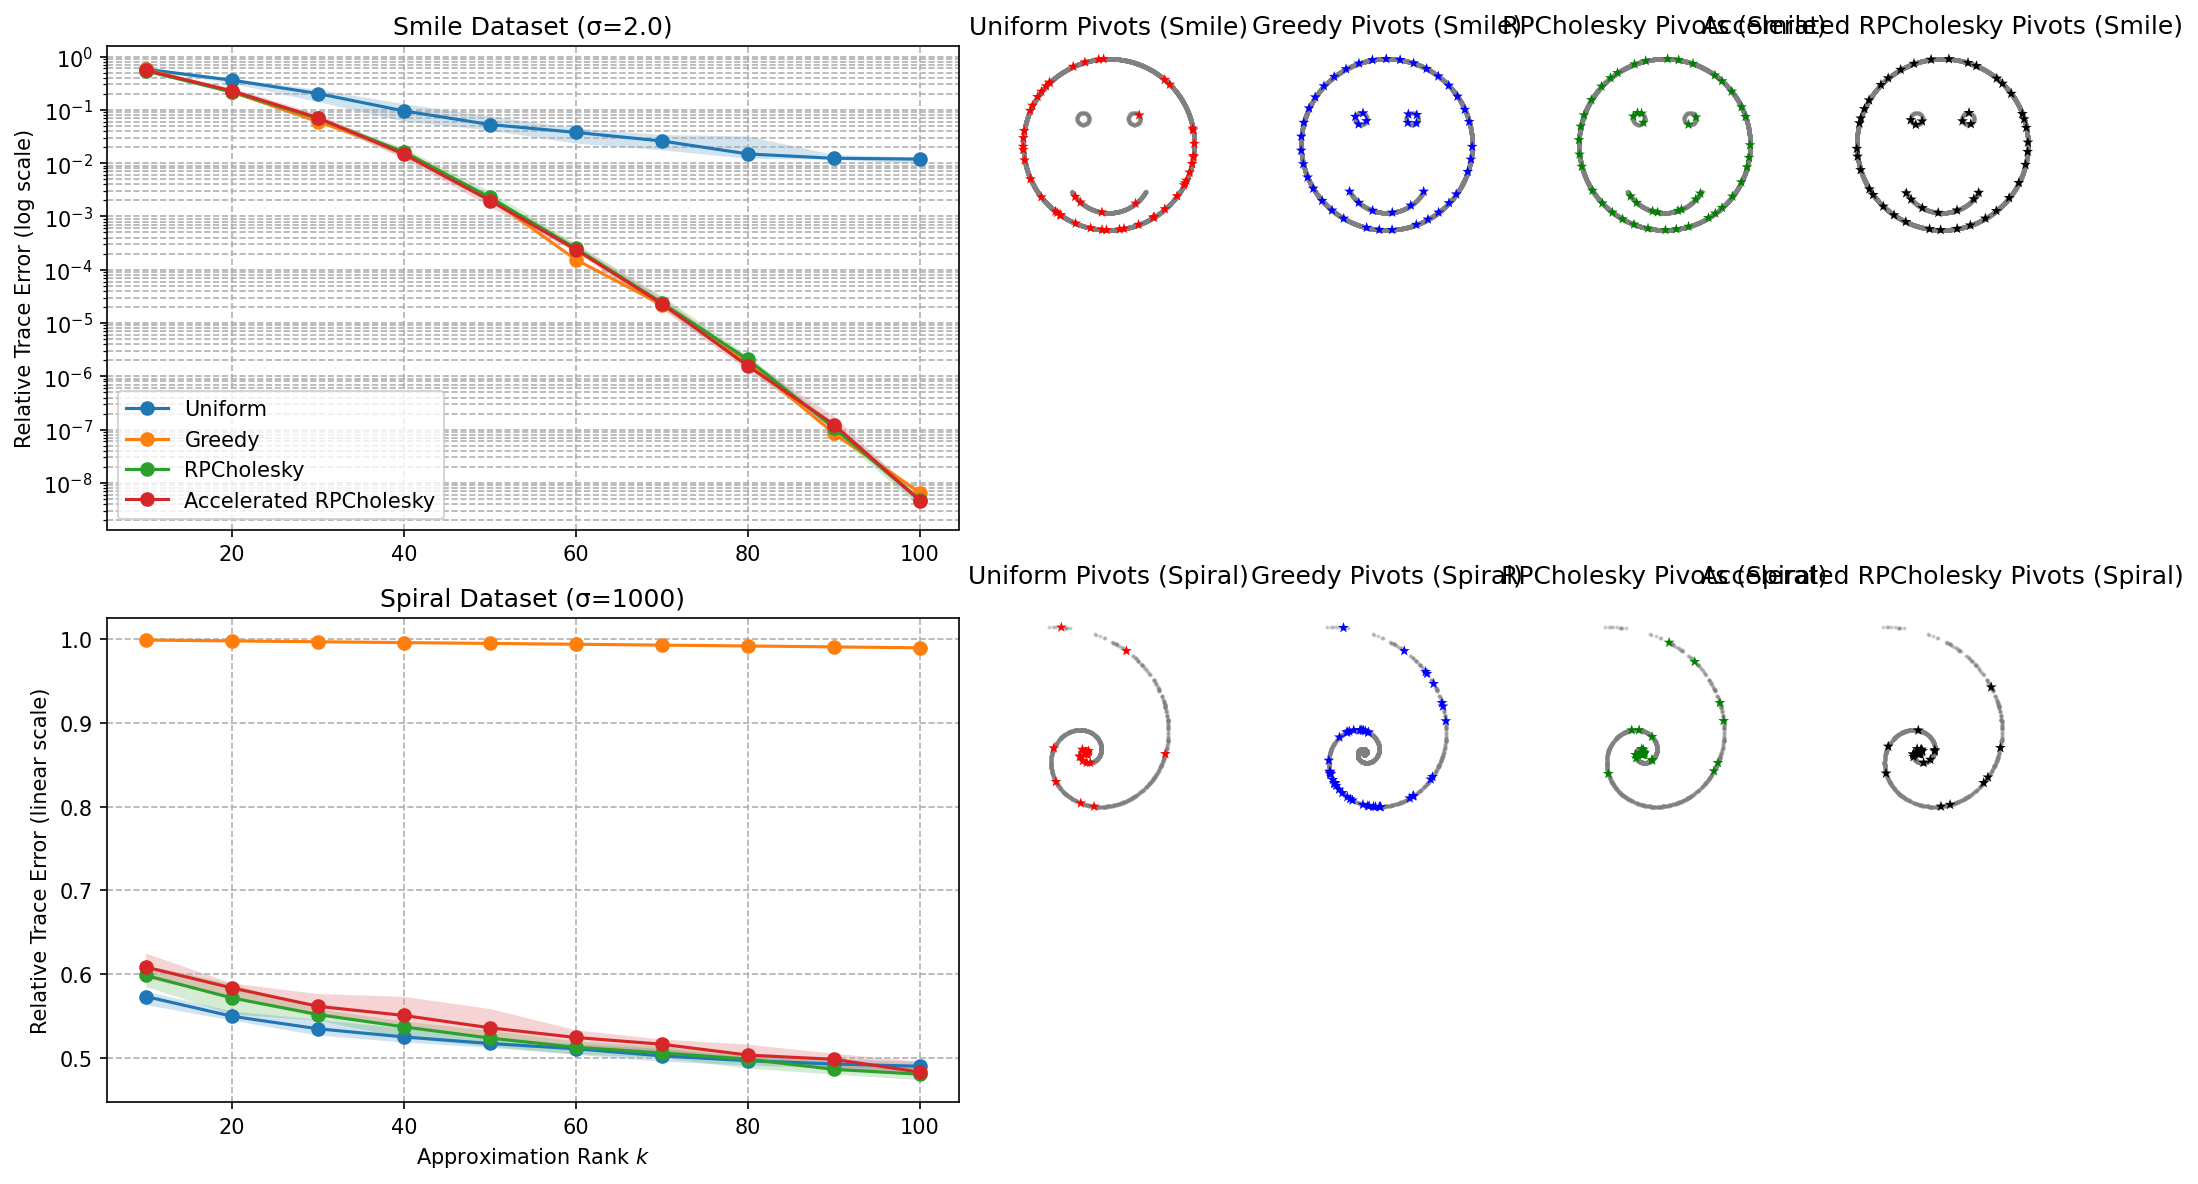

In [ ]:
def run_trials(X, sigma, max_k=100, n_trials=20):
    A = gaussian_kernel(X, sigma)
    methods = {
        "RPCholesky": rpcholesky,
        "Greedy": greedy_pivoted_cholesky,
        "Uniform": uniform_pivoted_cholesky,
        "Accelerated RPCholesky": accelerated_rpcholesky
    }
    
    k_steps = list(range(10, max_k + 1, 10))
    error_stats = {name: np.zeros((len(k_steps), n_trials)) for name in methods}
    pivot_examples = {name: [] for name in methods}

    for trial in range(n_trials):
        for name, method in methods.items():
            S, F = method(A, max_k)
            
            for idx, k in enumerate(k_steps):
                A_hat = F[:, :k] @ F[:, :k].T.conj()
                error_stats[name][idx, trial] = np.trace(A - A_hat) / np.trace(A)
                
            if trial == n_trials - 1:
                pivot_examples[name] = S  # Store pivot indices

    results = {}
    for name in methods:
        median = np.median(error_stats[name], axis=1)
        q20 = np.percentile(error_stats[name], 20, axis=1)
        q80 = np.percentile(error_stats[name], 80, axis=1)
        results[name] = (median, q20, q80)
    
    return results, pivot_examples

# =============================================
# 5. Visualization with Semi-Log Plots
# =============================================

def plot_pivots(data, pivots, ax):
    ax.scatter(data[:, 0], data[:, 1], s=1, c='gray', alpha=0.3)
    colors = {'Uniform': 'red', 'Greedy': 'blue', 'RPCholesky': 'green', 'Accelerated RPCholesky': 'black'}
    for name in pivots:
        idxs = pivots[name][:50]  # First 50 pivots
        ax.scatter(data[idxs, 0], data[idxs, 1], 
                   s=50, marker='*', edgecolor='k',
                   label=name, c=colors[name])
    ax.axis('equal')
    ax.legend()

def create_figure(smile_results, smile_pivots, spiral_results, spiral_pivots):
    fig = plt.figure(figsize=(14, 8), dpi=150)
    #gs = GridSpec(4, 4, width_ratios=[1, 0.3, 0.3, 0.3], height_ratios=[1, 1, 1, 1])
    gs = GridSpec(
        4, 5,
        width_ratios=[1, 0.3, 0.3, 0.3, 0.3],  # now 5 columns
        height_ratios=[1, 1, 1, 1],
    )
    
    # -----------------------------------------
    # Error Plots
    # -----------------------------------------
    # Smile (log scale)
    ax_smile = fig.add_subplot(gs[0:2, 0])
    k_range = np.arange(10, 101, 10)
    for name in ["Uniform", "Greedy", "RPCholesky", "Accelerated RPCholesky"]:
        mean, q20, q80 = smile_results[name]
        ax_smile.plot(k_range, mean, 'o-', label=name)
        ax_smile.fill_between(k_range, q20, q80, alpha=0.2)
    ax_smile.set_yscale('log')
    ax_smile.set_title("Smile Dataset (σ=2.0)")
    ax_smile.set_ylabel("Relative Trace Error (log scale)")
    ax_smile.grid(True, which='both', ls='--')
    ax_smile.legend()
    
    # Spiral (linear scale)
    ax_spiral = fig.add_subplot(gs[2:4, 0])
    for name in ["Uniform", "Greedy", "RPCholesky", "Accelerated RPCholesky"]:
        mean, q20, q80 = spiral_results[name]
        ax_spiral.plot(k_range, mean, 'o-', label=name)
        ax_spiral.fill_between(k_range, q20, q80, alpha=0.2)
    ax_spiral.set_title("Spiral Dataset (σ=1000)")
    ax_spiral.set_xlabel("Approximation Rank $k$")
    ax_spiral.set_ylabel("Relative Trace Error (linear scale)")
    ax_spiral.grid(True, ls='--')

    # -----------------------------------------
    # Pivot Visualization (Separate Subplots)
    # -----------------------------------------
    colors = {'Uniform': 'red', 'Greedy': 'blue', 'RPCholesky': 'green', 'Accelerated RPCholesky': 'black'}
    
    # Smile Pivots
    for col, name in enumerate(["Uniform", "Greedy", "RPCholesky", "Accelerated RPCholesky"], start=1):
        ax = fig.add_subplot(gs[0, col])
        ax.scatter(smile_data[:, 0], smile_data[:, 1], s=1, c='gray', alpha=0.3)
        idxs = smile_pivots[name][:50]
        ax.scatter(smile_data[idxs, 0], smile_data[idxs, 1], 
                   s=30, marker='*', edgecolor='none', c=colors[name])  # No edge color
        ax.set_title(f"{name} Pivots (Smile)")
        ax.axis('equal')
        ax.axis('off')
    
    # Spiral Pivots
    for col, name in enumerate(["Uniform", "Greedy", "RPCholesky", "Accelerated RPCholesky"], start=1):
        ax = fig.add_subplot(gs[2, col])
        ax.scatter(spiral_data[:, 0], spiral_data[:, 1], s=1, c='gray', alpha=0.3)
        idxs = spiral_pivots[name][:50]
        ax.scatter(spiral_data[idxs, 0], spiral_data[idxs, 1], 
                   s=30, marker='*', edgecolor='none', c=colors[name])  # No edge color
        ax.set_title(f"{name} Pivots (Spiral)")
        ax.axis('equal')
        ax.axis('off')

    plt.tight_layout()
    plt.savefig('final_comparison_updated.png', bbox_inches='tight')
    plt.show()

# =============================================
# 6. Main Execution
# =============================================

if __name__ == "__main__":
    # Run experiments
    smile_results, smile_pivots = run_trials(smile_data, sigma=2.0, n_trials=10)
    spiral_results, spiral_pivots = run_trials(spiral_data, sigma=1000, n_trials=10)
    
    # Create final figure
    create_figure(smile_results, smile_pivots, spiral_results, spiral_pivots)

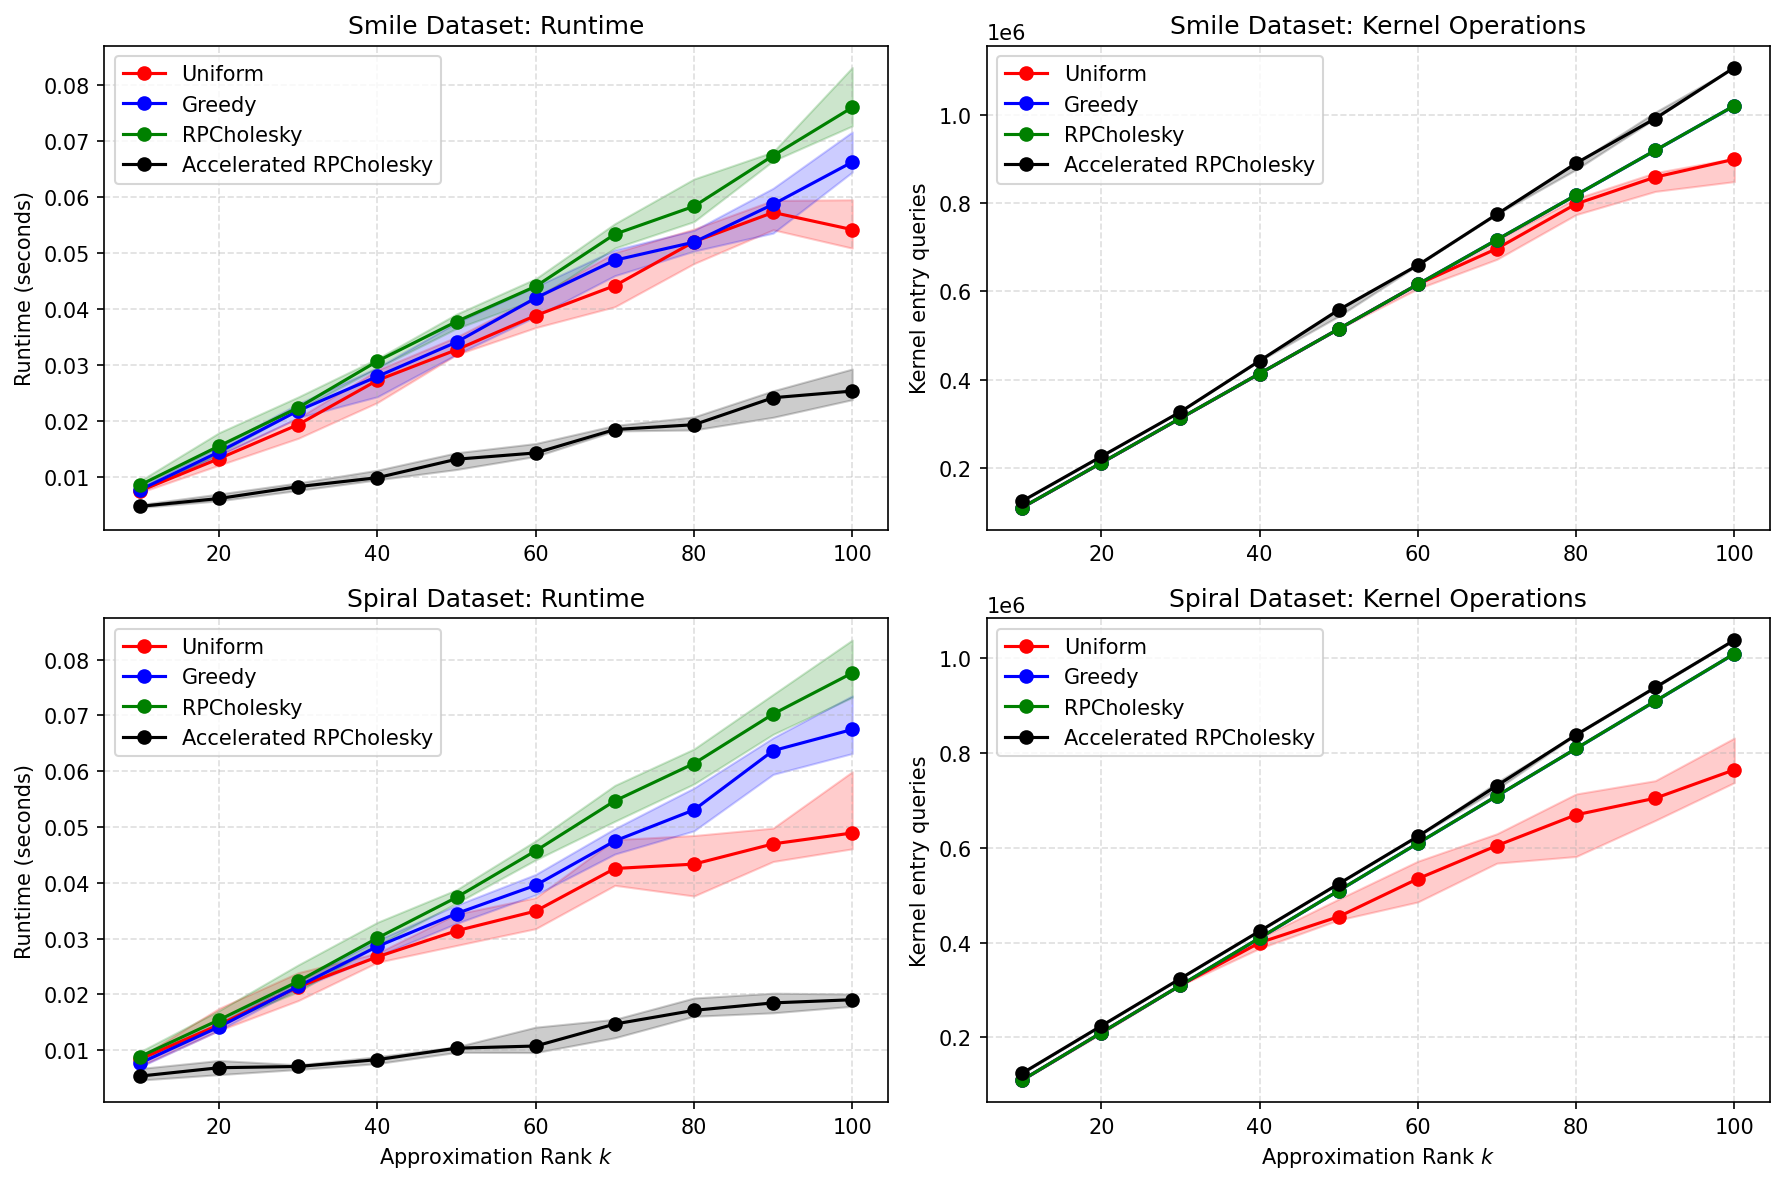

In [ ]:
# ============================================================
# Timing + kernel-operation benchmark (minimal changes style)
# - Measures runtime + KernelMatrix query counts vs rank k
# - Keeps method names consistent with earlier figure
# ============================================================

from __future__ import annotations

import sys
from pathlib import Path
from time import perf_counter

import numpy as np
import matplotlib.pyplot as plt


def _ensure_src_on_path():
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "src" / "my_cholesky").exists():
            src = p / "src"
            if str(src) not in sys.path:
                sys.path.insert(0, str(src))
            return
    raise RuntimeError("Could not locate `src/my_cholesky` from current working directory")


_ensure_src_on_path()

from my_cholesky.arpcholesky import arpcholesky
from my_cholesky.matrix import KernelMatrix
from my_cholesky.rpcholesky_variants import block_rpcholesky, simple_rpcholesky


def greedy_pivoted_cholesky_lazy(A, k):
    """Greedy pivoted Cholesky that works with KernelMatrix/AbstractPSDMatrix."""
    n = A.shape[0]
    F = np.zeros((n, k), dtype=float)
    d = np.asarray(A.diag(), dtype=float).copy()
    S = []

    for i in range(k):
        if np.max(d) <= 1e-14:
            break
        s_i = int(np.argmax(d))
        S.append(s_i)

        g_si = float(d[s_i])
        if g_si <= 0:
            raise ValueError("Diagonal entry is non-positive, numerical error detected.")

        g = np.asarray(A[:, s_i], dtype=float)
        if i > 0:
            g = g - (F[:, :i] @ F[s_i, :i].T)

        F[:, i] = g / np.sqrt(g_si)
        d = d - F[:, i] ** 2
        d = np.maximum(d, 0)

    return S, F


def uniform_pivoted_cholesky_lazy(A, k, rng=None):
    """Uniform random pivoted Cholesky (without replacement) for KernelMatrix."""
    if rng is None:
        rng = np.random.default_rng()

    n = A.shape[0]
    if k > n:
        raise ValueError("k must be <= n")

    F = np.zeros((n, k), dtype=float)
    d = np.asarray(A.diag(), dtype=float).copy()
    S = []

    # sample pivots once, without replacement
    pivots = rng.choice(n, size=k, replace=False)

    for i, s_i in enumerate(pivots):
        if np.max(d) <= 1e-14:
            break
        s_i = int(s_i)
        S.append(s_i)

        g_si = float(d[s_i])
        if g_si <= 0:
            # skip numerically-bad pivots; continue
            continue

        g = np.asarray(A[:, s_i], dtype=float)
        if i > 0:
            g = g - (F[:, :i] @ F[s_i, :i].T)

        F[:, i] = g / np.sqrt(g_si)
        d = d - F[:, i] ** 2
        d = np.maximum(d, 0)

    return S, F


def rpcholesky_lazy(A, k, rng=None):
    """Randomly pivoted Cholesky that works with KernelMatrix/AbstractPSDMatrix."""
    if rng is None:
        rng = np.random.default_rng()

    n = A.shape[0]
    F = np.zeros((n, k), dtype=float)
    d = np.asarray(A.diag(), dtype=float).copy()
    S = []

    for i in range(k):
        mass = float(np.sum(d))
        if np.max(d) <= 1e-14 or mass <= 0:
            break

        prob = d / mass
        s_i = int(rng.choice(n, p=prob))
        S.append(s_i)

        g_si = float(d[s_i])
        if g_si <= 0:
            raise ValueError("Diagonal entry is non-positive, numerical error detected.")

        g = np.asarray(A[:, s_i], dtype=float)
        if i > 0:
            g = g - (F[:, :i] @ F[s_i, :i].T)

        F[:, i] = g / np.sqrt(g_si)
        d = d - F[:, i] ** 2
        d = np.maximum(d, 0)

    return S, F


def run_timing_and_queries_trials(X, bandwidth, max_k=100, n_trials=10, b=120):
    """Return (median,q20,q80) bands for runtime and query counts vs k."""

    # Lazy kernel matrix so we can count kernel-entry accesses
    A = KernelMatrix(X, kernel="gaussian", bandwidth=bandwidth, count_queries=True)

    methods = {
        "RPCholesky": lambda k: rpcholesky_lazy(A, k),
        "Greedy": lambda k: greedy_pivoted_cholesky_lazy(A, k),
        "Uniform": lambda k: uniform_pivoted_cholesky_lazy(A, k),
        "Accelerated RPCholesky": lambda k: arpcholesky(A, k, b=b),
        # If you want the block variant too, uncomment:
        # "Block RPCholesky": lambda k: block_rpcholesky(A, k, b=b),
    }

    k_steps = list(range(10, max_k + 1, 10))
    time_stats = {name: np.zeros((len(k_steps), n_trials)) for name in methods}
    query_stats = {name: np.zeros((len(k_steps), n_trials)) for name in methods}

    for trial in range(n_trials):
        for name, fn in methods.items():
            for idx, k in enumerate(k_steps):
                A.reset()
                start = perf_counter()
                _ = fn(k)
                time_stats[name][idx, trial] = perf_counter() - start
                query_stats[name][idx, trial] = A.num_queries()

    results = {}
    for name in methods:
        time_median = np.median(time_stats[name], axis=1)
        time_q20 = np.percentile(time_stats[name], 20, axis=1)
        time_q80 = np.percentile(time_stats[name], 80, axis=1)

        query_median = np.median(query_stats[name], axis=1)
        query_q20 = np.percentile(query_stats[name], 20, axis=1)
        query_q80 = np.percentile(query_stats[name], 80, axis=1)

        results[name] = {
            "time": (time_median, time_q20, time_q80),
            "queries": (query_median, query_q20, query_q80),
        }

    return k_steps, results


def plot_time_and_queries(smile_k, smile_res, spiral_k, spiral_res, max_k=100):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), dpi=150)

    methods = ["Uniform", "Greedy", "RPCholesky", "Accelerated RPCholesky"]
    colors = {
        "Uniform": "red",
        "Greedy": "blue",
        "RPCholesky": "green",
        "Accelerated RPCholesky": "black",
    }

    # Smile Runtime
    ax = axes[0, 0]
    for name in methods:
        median, q20, q80 = smile_res[name]["time"]
        ax.plot(smile_k, median, "o-", label=name, color=colors[name])
        ax.fill_between(smile_k, q20, q80, alpha=0.2, color=colors[name])
    ax.set_title("Smile Dataset: Runtime")
    ax.set_ylabel("Runtime (seconds)")
    ax.grid(True, ls="--", alpha=0.4)
    ax.legend()

    # Smile Queries
    ax = axes[0, 1]
    for name in methods:
        median, q20, q80 = smile_res[name]["queries"]
        ax.plot(smile_k, median, "o-", label=name, color=colors[name])
        ax.fill_between(smile_k, q20, q80, alpha=0.2, color=colors[name])
    ax.set_title("Smile Dataset: Kernel Operations")
    ax.set_ylabel("Kernel entry queries")
    ax.grid(True, ls="--", alpha=0.4)
    ax.legend()

    # Spiral Runtime
    ax = axes[1, 0]
    for name in methods:
        median, q20, q80 = spiral_res[name]["time"]
        ax.plot(spiral_k, median, "o-", label=name, color=colors[name])
        ax.fill_between(spiral_k, q20, q80, alpha=0.2, color=colors[name])
    ax.set_title("Spiral Dataset: Runtime")
    ax.set_xlabel("Approximation Rank $k$")
    ax.set_ylabel("Runtime (seconds)")
    ax.grid(True, ls="--", alpha=0.4)
    ax.legend()

    # Spiral Queries
    ax = axes[1, 1]
    for name in methods:
        median, q20, q80 = spiral_res[name]["queries"]
        ax.plot(spiral_k, median, "o-", label=name, color=colors[name])
        ax.fill_between(spiral_k, q20, q80, alpha=0.2, color=colors[name])
    ax.set_title("Spiral Dataset: Kernel Operations")
    ax.set_xlabel("Approximation Rank $k$")
    ax.set_ylabel("Kernel entry queries")
    ax.grid(True, ls="--", alpha=0.4)
    ax.legend()

    plt.tight_layout()
    plt.show()


# ---- Example usage (expects smile_data and spiral_data already exist) ----

smile_k, smile_tq = run_timing_and_queries_trials(
    smile_data, bandwidth=2.0, max_k=100, n_trials=10, b=120
)
spiral_k, spiral_tq = run_timing_and_queries_trials(
    spiral_data, bandwidth=1000.0, max_k=100, n_trials=10, b=120
)

plot_time_and_queries(smile_k, smile_tq, spiral_k, spiral_tq)


In [ ]:
# ============================================================
# NEW CELL: Runtime + kernel-ops (uses earlier notebook methods)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from time import perf_counter


def gaussian_kernel_counted(X, sigma):
    """Compute full Gaussian kernel matrix and return (K, num_kernel_ops)."""
    n = X.shape[0]
    sq_dists = (
        np.sum(X**2, axis=1)[:, None]
        + np.sum(X**2, axis=1)[None, :]
        - 2 * (X @ X.T)
    )
    K = np.exp(-sq_dists / (2 * sigma**2))
    return K, int(n * n)


def run_time_and_kernelops_trials(X, sigma, max_k=100, n_trials=10):
    """Benchmarks runtime + kernel ops vs k for existing methods."""

    methods = {
        "RPCholesky": rpcholesky,
        "Greedy": greedy_pivoted_cholesky,
        "Uniform": uniform_pivoted_cholesky,
        "Accelerated RPCholesky": accelerated_rpcholesky,
    }

    k_steps = list(range(10, max_k + 1, 10))
    time_stats = {name: np.zeros((len(k_steps), n_trials)) for name in methods}
    kernelops_stats = {name: np.zeros((len(k_steps), n_trials)) for name in methods}

    for trial in range(n_trials):
        K, build_ops = gaussian_kernel_counted(X, sigma)

        for name, method in methods.items():
            for idx, k in enumerate(k_steps):
                start = perf_counter()
                _S, _F = method(K, k)
                time_stats[name][idx, trial] = perf_counter() - start
                kernelops_stats[name][idx, trial] = build_ops

    results = {}
    for name in methods:
        time_median = np.median(time_stats[name], axis=1)
        time_q20 = np.percentile(time_stats[name], 20, axis=1)
        time_q80 = np.percentile(time_stats[name], 80, axis=1)

        ops_median = np.median(kernelops_stats[name], axis=1)
        ops_q20 = np.percentile(kernelops_stats[name], 20, axis=1)
        ops_q80 = np.percentile(kernelops_stats[name], 80, axis=1)

        results[name] = {
            "time": (time_median, time_q20, time_q80),
            "kernel_ops": (ops_median, ops_q20, ops_q80),
        }

    return k_steps, results


def plot_time_and_kernelops(smile_k, smile_res, spiral_k, spiral_res):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), dpi=150)

    methods = ["Uniform", "Greedy", "RPCholesky", "Accelerated RPCholesky"]
    colors = {
        "Uniform": "red",
        "Greedy": "blue",
        "RPCholesky": "green",
        "Accelerated RPCholesky": "black",
    }

    # Smile Runtime
    ax = axes[0, 0]
    for name in methods:
        median, q20, q80 = smile_res[name]["time"]
        ax.plot(smile_k, median, "o-", label=name, color=colors[name])
        ax.fill_between(smile_k, q20, q80, alpha=0.2, color=colors[name])
    ax.set_title("Smile Dataset: Runtime")
    ax.set_ylabel("Runtime (seconds)")
    ax.grid(True, ls="--", alpha=0.4)
    ax.legend()

    # Smile Kernel Ops
    ax = axes[0, 1]
    for name in methods:
        median, q20, q80 = smile_res[name]["kernel_ops"]
        ax.plot(smile_k, median, "o-", label=name, color=colors[name])
        ax.fill_between(smile_k, q20, q80, alpha=0.2, color=colors[name])
    ax.set_title("Smile Dataset: Kernel Operations")
    ax.set_ylabel("# kernel evaluations to build K")
    ax.grid(True, ls="--", alpha=0.4)
    ax.legend()

    # Spiral Runtime
    ax = axes[1, 0]
    for name in methods:
        median, q20, q80 = spiral_res[name]["time"]
        ax.plot(spiral_k, median, "o-", label=name, color=colors[name])
        ax.fill_between(spiral_k, q20, q80, alpha=0.2, color=colors[name])
    ax.set_title("Spiral Dataset: Runtime")
    ax.set_xlabel("Approximation Rank $k$")
    ax.set_ylabel("Runtime (seconds)")
    ax.grid(True, ls="--", alpha=0.4)
    ax.legend()

    # Spiral Kernel Ops
    ax = axes[1, 1]
    for name in methods:
        median, q20, q80 = spiral_res[name]["kernel_ops"]
        ax.plot(spiral_k, median, "o-", label=name, color=colors[name])
        ax.fill_between(spiral_k, q20, q80, alpha=0.2, color=colors[name])
    ax.set_title("Spiral Dataset: Kernel Operations")
    ax.set_xlabel("Approximation Rank $k$")
    ax.set_ylabel("# kernel evaluations to build K")
    ax.grid(True, ls="--", alpha=0.4)
    ax.legend()

    plt.tight_layout()
    plt.show()


# ---- Run (expects smile_data and spiral_data already exist) ----

smile_k, smile_bench = run_time_and_kernelops_trials(smile_data, sigma=2.0, max_k=100, n_trials=10)
spiral_k, spiral_bench = run_time_and_kernelops_trials(spiral_data, sigma=1000.0, max_k=100, n_trials=10)

plot_time_and_kernelops(smile_k, smile_bench, spiral_k, spiral_bench)


# Kernel Ridge Regression for QM9 Data---Predicting HOMO Energy  

In [29]:
"""
QM9 KRR via Nystrom (using QMlib) with Custom Sampling Methods
--------------------------------------------------------------------------
This script applies (`uniform_pivoted_cholesky`, 
`greedy_pivoted_cholesky`, and `rpcholesky`) to Nystrom-based Kernel Ridge Regression.

### CSV File Assumptions:
- Located at `/Users/zhenyuhong/qm9.csv`
- Contains **only numeric columns** (or non-numeric columns have been dropped).
- All columns **except the last** are features; **last column** is the target property.

### Key Parameters:
- **Laplacian kernel bandwidth** (`sigma`) = `5120.0`  
- **Regularization parameter** (`lambda`) = `1e-8`  
- Uses different **sampling strategies** for selecting Nystrom landmarks.

### Outputs:
- Compares **SMAPE across sampling methods**
- **Plots relative trace norm error** per method.
"""


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from qmllib.kernels import laplacian_kernel


# --- Load CSV Data ---
def load_qm9_csv(filepath):
    """
    Loads QM9 data from a CSV file, ensuring only numeric columns are used.
    """
    data = pd.read_csv(filepath)
    print("CSV Data Preview:\n", data.head())

    # Select only numeric columns (drop strings or categorical data)
    numeric_data = data.select_dtypes(include=["number"])
    if numeric_data.shape[1] == 0:
        raise ValueError("No numeric columns found in the CSV file.")

    print("Numeric columns found:", numeric_data.columns.tolist())

    # Assume all but the last column are features; last column is the target.
    features = numeric_data.iloc[:, :-1].to_numpy()
    target   = numeric_data.iloc[:, -1].to_numpy()
    return features, target

# --- Nystrom Approximation ---
def nystrom_KRR(train_X, train_y, sigma, lamb, m, sample_method="uniform"):
    """
    Scalable Nystrom KRR with correct regularization and trace error.
    Avoids full kernel matrix for large datasets.
    """
    n = train_X.shape[0]

    # Select landmarks using specified method (without full kernel matrix)
    if sample_method == "uniform":
        landmark_idx = np.random.choice(n, size=m, replace=False)
    elif sample_method == "greedy":
        # Greedy selection using diagonal elements only
        diag = np.array([laplacian_kernel(x.reshape(1,-1), x.reshape(1,-1), sigma) 
                        for x in train_X]).flatten()
        landmark_idx = np.argpartition(-diag, m)[:m]
    elif sample_method == "rpcholesky":
        # For demonstration - this still needs full kernel matrix
        K = laplacian_kernel(train_X, train_X, sigma)
        landmark_idx, _ = rpcholesky(K, m)
    else:
        raise ValueError("Invalid sampling method")

    landmarks = train_X[landmark_idx]

    # Compute required kernel submatrices
    K_nm = laplacian_kernel(train_X, landmarks, sigma)  # (n, m)
    K_mm = laplacian_kernel(landmarks, landmarks, sigma)  # (m, m)

    # CORRECT REGULARIZATION 
    A = K_nm.T @ K_nm + lamb * K_mm  # No pre-diagonal modification
    b = K_nm.T @ train_y
    
    # Numerically stable solve
    try:
        beta = np.linalg.solve(A, b)
    except np.linalg.LinAlgError:
        beta = np.linalg.lstsq(A, b, rcond=1e-6)[0]

    # TRACE ERROR COMPUTATION (EFFICIENT)
    trace_K_nn = n  # Sum of Laplacian diagonals (all 1s)
    K_mm_inv = np.linalg.pinv(K_mm)
    K_approx_diag = np.einsum("ij,jk,ik->i", K_nm, K_mm_inv, K_nm)
    trace_error = abs(trace_K_nn - np.sum(K_approx_diag)) / trace_K_nn

    return beta, landmarks, trace_error



# --- Prediction Function ---
def predict_nystrom(test_X, landmarks, sigma, beta):
    """
    Predicts values using a **Nystrom approximation**.
    """
    K_test = laplacian_kernel(test_X, landmarks, sigma)
    return np.dot(K_test, beta)

# --- Evaluation Metrics ---
def mean_squared_error(true, pred):
    return np.mean((true - pred) ** 2)

def mean_absolute_error(true, pred):
    return np.mean(np.abs(true - pred))

def SMAPE(true, pred):
    return np.mean(np.abs(true - pred) / ((np.abs(true) + np.abs(pred)) / 2))

# --- Main Function ---
def main():
    # Load CSV
    csv_path = '/Users/zhenyuhong/qm9.csv'
    features, target = load_qm9_csv(csv_path)
    
    # Standardize features
    scaler = StandardScaler()
    features = scaler.fit_transform(features)

    # Split dataset: 80% training, 20% testing
    n_samples = features.shape[0]
    num_train = int(0.8 * n_samples)
    train_X, train_y = features[:num_train], target[:num_train]
    test_X, test_y = features[num_train:], target[num_train:]

    print(f"Training Samples: {train_X.shape[0]}, Testing Samples: {test_X.shape[0]}")

    # KRR Hyperparameters
    sigma = 512.0   # Kernel bandwidth
    lamb = 1e-8      # Regularization parameter
    landmark_sizes = [200, 400, 600, 800, 1000]
    num_trials = 10  # Number of trials per landmark size

    methods = ["rpcholesky","uniform", "greedy"]
    results = {method: {} for method in methods}
    trace_errors = {method: [] for method in methods}

    # Loop over methods
    for method in methods:
        print(f"\nMethod: {method.upper()}")
        for m in landmark_sizes:
            mse_list, mae_list, smape_list, trace_error_list = [], [], [], []
            print(f"Landmark size: {m}")

            for i in range(num_trials):
                beta, landmarks, trace_error = nystrom_KRR(train_X, train_y, sigma, lamb, m, method)
                pred = predict_nystrom(test_X, landmarks, sigma, beta)

                mse_list.append(mean_squared_error(test_y, pred))
                mae_list.append(mean_absolute_error(test_y, pred))
                smape_list.append(SMAPE(test_y, pred))
                trace_error_list.append(trace_error)
                
                print(f"Trial {i}: MSE={mse_list[-1]:.4f}, MAE={mae_list[-1]:.4f}, SMAPE={smape_list[-1]:.4f}, TraceErr={trace_error:.4f}")

            results[method][str(m)] = {
                "MSE_mean": np.mean(mse_list),
                "MAE_mean": np.mean(mae_list),
                "SMAPE_mean": np.mean(smape_list),
            }
            trace_errors[method].append(np.mean(trace_error_list))

    # --- Plot SMAPE Comparison ---
    plt.figure(figsize=(10, 5))
    for method in methods:
        plt.plot(landmark_sizes, [results[method][str(m)]["SMAPE_mean"] for m in landmark_sizes], 'o-', label=method)
    plt.xlabel("Landmark size (m)")
    plt.ylabel("SMAPE")
    plt.title("SMAPE Comparison Across Sampling Methods")
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- Plot Relative Trace Norm Error ---
    plt.figure(figsize=(10, 5))
    for method in methods:
        plt.plot(landmark_sizes, trace_errors[method], 'o-', label=method)
    plt.xlabel("Landmark size (m)")
    plt.ylabel("Relative Trace Norm Error")
    plt.title("Relative Trace Norm Error Across Sampling Methods")
    plt.legend()
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    main()


ModuleNotFoundError: No module named 'qmllib'

In [ ]:
print("Hello World")

Hello World


In [ ]:
# ============================================================
# Benchmark: runtime and kernel-query counts vs rank k
# (Uses my_cholesky KernelMatrix so we DON'T materialize A)
# ============================================================

from __future__ import annotations

import os
import sys
from time import perf_counter

import numpy as np
import matplotlib.pyplot as plt

# Allow importing the local src/ package when running the notebook.
PROJECT_ROOT = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
SRC_PATH = os.path.join(PROJECT_ROOT, "src")
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

from my_cholesky.arpcholesky import arpcholesky
from my_cholesky.matrix import KernelMatrix
from my_cholesky.rpcholesky_variants import block_rpcholesky, simple_rpcholesky


def benchmark_query_and_time(X: np.ndarray, ks, bandwidth: float, b: int = 120, trials: int = 3):
    """Benchmark methods on a lazy KernelMatrix.

    Returns a dict:
      results[method] = {
        'time_mean': array(len(ks)),
        'time_std':  array(len(ks)),
        'queries_mean': array(len(ks)),
        'queries_std':  array(len(ks)),
      }
    """
    ks = list(ks)

    # Lazy kernel matrix (entries computed on demand)
    A = KernelMatrix(X, kernel="gaussian", bandwidth=bandwidth, count_queries=True)

    methods = {
        "Basic": lambda k: simple_rpcholesky(A, k),
        "Block": lambda k: block_rpcholesky(A, k, b=b),
        "Accel": lambda k: arpcholesky(A, k, b=b),
    }

    results = {
        name: {
            "time_mean": np.zeros(len(ks)),
            "time_std": np.zeros(len(ks)),
            "queries_mean": np.zeros(len(ks)),
            "queries_std": np.zeros(len(ks)),
        }
        for name in methods
    }

    for i, k in enumerate(ks):
        for name, fn in methods.items():
            trial_times = np.zeros(trials)
            trial_queries = np.zeros(trials)

            for t in range(trials):
                A.reset()  # reset query counter
                start = perf_counter()
                _ = fn(k)
                trial_times[t] = perf_counter() - start
                trial_queries[t] = A.num_queries()

            results[name]["time_mean"][i] = float(np.mean(trial_times))
            results[name]["time_std"][i] = float(np.std(trial_times))
            results[name]["queries_mean"][i] = float(np.mean(trial_queries))
            results[name]["queries_std"][i] = float(np.std(trial_queries))

    return results


# --- Example usage on the existing datasets ---
# NOTE: start with smaller N if this is slow in a notebook.

np.random.seed(42)
smile_data = generate_smile(N_face=3000, N_mouth=300, N_eye=50)  # smaller for speed
spiral_data = generate_spiral(N=4000)

ks = [10, 25, 50, 75, 100, 150, 200]

print("Benchmarking SMILE (Gaussian kernel, bandwidth=2.0)...")
smile_bench = benchmark_query_and_time(smile_data, ks=ks, bandwidth=2.0, b=120, trials=3)

print("Benchmarking SPIRAL (Gaussian kernel, bandwidth=1000.0)...")
spiral_bench = benchmark_query_and_time(spiral_data, ks=ks, bandwidth=1000.0, b=120, trials=3)


def print_benchmark_table(title: str, bench, ks):
    print("\n" + title)
    print("k\tmethod\ttime_mean(s)\tqueries_mean")
    for i, k in enumerate(ks):
        for method in ["Basic", "Block", "Accel"]:
            print(
                f"{k}\t{method}\t{bench[method]['time_mean'][i]:.4f}\t\t{bench[method]['queries_mean'][i]:.0f}"
            )
        print()


print_benchmark_table("SMILE results", smile_bench, ks)
print_benchmark_table("SPIRAL results", spiral_bench, ks)


def plot_benchmark(bench, ks, title_prefix: str):
    plt.figure(figsize=(7, 4))
    for method in ["Basic", "Block", "Accel"]:
        plt.plot(ks, bench[method]["time_mean"], marker="o", label=method)
    plt.xlabel("Rank k")
    plt.ylabel("Runtime (s)")
    plt.title(f"{title_prefix}: runtime vs k")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    for method in ["Basic", "Block", "Accel"]:
        plt.plot(ks, bench[method]["queries_mean"], marker="o", label=method)
    plt.xlabel("Rank k")
    plt.ylabel("Kernel entry queries (counted accesses)")
    plt.title(f"{title_prefix}: kernel queries vs k")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_benchmark(smile_bench, ks, "SMILE")
plot_benchmark(spiral_bench, ks, "SPIRAL")
